In [11]:
# ----------------------------- 1. 라이브러리 불러오기 -----------------------------
import pandas as pd
import shap
import lime
import lime.lime_tabular
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import display, HTML
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

shap.initjs()

In [12]:
# ----------------------------- 2. 데이터 로딩 및 이진 분류 변환 -----------------------------
path = "C:/xai/diabetes_012_health_indicators_BRFSS2015.csv"
df = pd.read_csv(path)

# 이진 분류로 변환 (0: 정상, 1: 전당뇨 또는 당뇨)
df['Diabetes_012'] = df['Diabetes_012'].apply(lambda x: 1 if x > 0 else 0)

y = df['Diabetes_012']
X = df.drop(columns=['Diabetes_012'])

# 정규화
for col in X.columns:
    if X[col].dtype in ['int64', 'float64']:
        X[col] = (X[col] - X[col].mean()) / X[col].std()

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)

In [24]:
# ----------------------------- 3. 모델 학습 -----------------------------
tabnet = TabNetClassifier(
    optimizer_params=dict(lr=0.02),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    seed=42
)

X_train_np = X_train.values
y_train_np = y_train.values
X_valid_np = X_valid.values
y_valid_np = y_valid.values

tabnet.fit(
    X_train_np, y_train_np,
    eval_set   = [(X_valid_np, y_valid_np)],
    max_epochs = 50,
    patience   = 20,
    batch_size = 2048,           # CPU면 1024 / GPU면 256 정도부터 시도
    virtual_batch_size = 128,
    num_workers = 0,
    drop_last   = False
)
mlp = MLPClassifier(hidden_layer_sizes=(64, 64),
                    activation='relu',
                    solver='adam',
                    max_iter=300,
                    random_state=42)

mlp.fit(X_train, y_train)

c:\xai\venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.38111 | val_0_auc: 0.79935 |  0:00:11s
epoch 1  | loss: 0.35377 | val_0_auc: 0.8103  |  0:00:22s
epoch 2  | loss: 0.35004 | val_0_auc: 0.81358 |  0:00:34s
epoch 3  | loss: 0.34801 | val_0_auc: 0.81592 |  0:00:45s
epoch 4  | loss: 0.34691 | val_0_auc: 0.81667 |  0:00:59s
epoch 5  | loss: 0.34524 | val_0_auc: 0.81996 |  0:01:12s
epoch 6  | loss: 0.34377 | val_0_auc: 0.82158 |  0:01:28s
epoch 7  | loss: 0.34436 | val_0_auc: 0.82139 |  0:01:42s
epoch 8  | loss: 0.34335 | val_0_auc: 0.82222 |  0:01:55s
epoch 9  | loss: 0.34261 | val_0_auc: 0.82169 |  0:02:08s
epoch 10 | loss: 0.34349 | val_0_auc: 0.82304 |  0:02:21s
epoch 11 | loss: 0.34288 | val_0_auc: 0.81965 |  0:02:34s
epoch 12 | loss: 0.3434  | val_0_auc: 0.82297 |  0:02:47s
epoch 13 | loss: 0.3419  | val_0_auc: 0.82453 |  0:02:59s
epoch 14 | loss: 0.34207 | val_0_auc: 0.82331 |  0:03:12s
epoch 15 | loss: 0.34161 | val_0_auc: 0.82488 |  0:03:24s
epoch 16 | loss: 0.34173 | val_0_auc: 0.82434 |  0:03:37s
epoch 17 | los

c:\xai\venv\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=300, random_state=42)

In [14]:
# ----------------------------- 4. 모델 평가 함수 -----------------------------
def evaluate_model(model, name, X_val, y_val):
    # model.predict()에 NumPy 배열을 전달
    y_pred = model.predict(X_val)
    
    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec  = recall_score(y_val, y_pred)
    f1   = f1_score(y_val, y_pred)
    
    print(f"\n{name} 성능")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    
    return acc, prec, rec, f1

evaluate_model(tabnet, "TabNet", X_valid_np, y_valid_np)
evaluate_model(mlp, "MLP", X_valid_np, y_valid_np)


TabNet 성능
Accuracy:  0.8498
Precision: 0.5619
Recall:    0.2130
F1-score:  0.3089

MLP 성능
Accuracy:  0.8416
Precision: 0.4950
Recall:    0.2453
F1-score:  0.3280


c:\xai\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


(0.8416311888994008,
 0.4949520444220091,
 0.24527829893683553,
 0.32800869783390485)

In [15]:
# ----------------------------- 5. SHAP (TreeExplainer + 샘플 제한) -----------------------------
X_sample = X_valid.sample(1000, random_state=42)

c:\xai\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(



🔍 SHAP (MLP)


  0%|          | 0/100 [00:00<?, ?it/s]c:\xai\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
c:\xai\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
c:\xai\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
c:\xai\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
c:\xai\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
c:\xai\venv\Lib\site-packages\sklearn\utils\validation.py:2739: Us

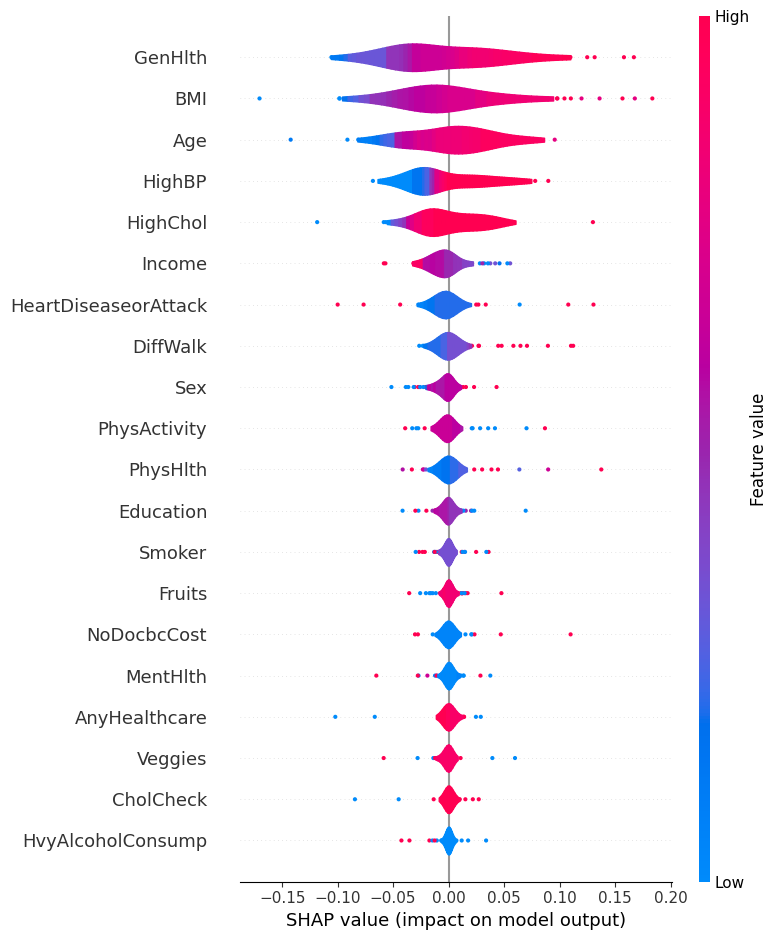

In [22]:
print("\n🔍 SHAP (MLP)")

# 1) 배경 / 샘플
background = shap.sample(X_train, 80, random_state=42)
X_sample   = X_valid.sample(100, random_state=42)

# 2) 클래스 1 확률만 반환하도록 래퍼 (속도 ↑)
f_prob = lambda data: mlp.predict_proba(data)[:, 1]

explainer = shap.KernelExplainer(f_prob, background)

# 3) SHAP 값 계산
shap_vals = explainer.shap_values(X_sample, nsamples=100)  # ndarray (N, n_feat+1)

# 4) 마지막 열(offset) 제거
if shap_vals.shape[1] == X_sample.shape[1] + 1:
    shap_vals = shap_vals[:, :-1]

# 5) summary_plot
shap.summary_plot(
    shap_vals,
    X_sample,                  # DataFrame!
    feature_names=X.columns,
    plot_type="violin"
)
plt.close()




🔍 SHAP (TABNET)


100%|██████████| 100/100 [00:20<00:00,  4.76it/s]


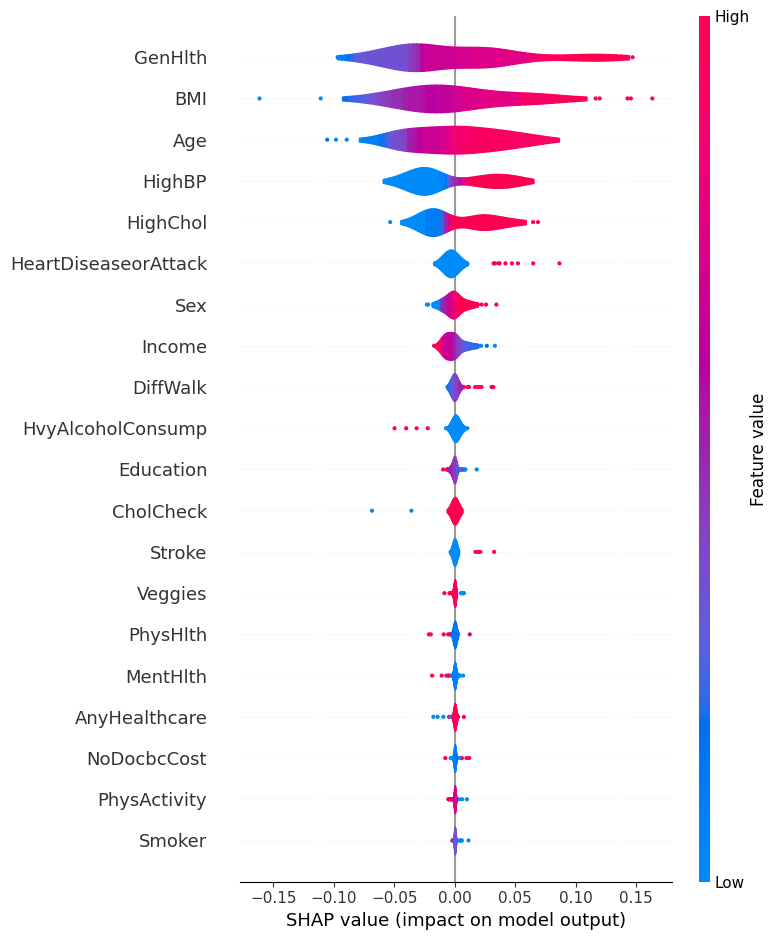

In [25]:
print("\n🔍 SHAP (TABNET)")

# 1) 배경 / 샘플
background = shap.sample(X_train, 80, random_state=42)
X_sample   = X_valid.sample(100, random_state=42)

# 2) 클래스 1 확률만 반환하도록 래퍼 (속도 ↑)
f_prob = lambda data: tabnet.predict_proba(data)[:, 1]

explainer = shap.KernelExplainer(f_prob, background)

# 3) SHAP 값 계산
shap_vals = explainer.shap_values(X_sample, nsamples=100)  # ndarray (N, n_feat+1)

# 4) 마지막 열(offset) 제거
if shap_vals.shape[1] == X_sample.shape[1] + 1:
    shap_vals = shap_vals[:, :-1]

# 5) summary_plot
shap.summary_plot(
    shap_vals,
    X_sample,                  # DataFrame!
    feature_names=X.columns,
    plot_type="violin"
)
plt.close()



In [18]:
# ----------------------------- 6. LIME 해석 예시 -----------------------------
print("\n🔍 LIME 해석 예시 (샘플 1개)")

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=['No Diabetes', 'Diabetes'],
    mode='classification'
)

# 샘플 선택
i = 0
sample = X_valid.values[i]

# mlp
print("\n📌 LIME (Mlp)")
exp_mlp = lime_explainer.explain_instance(sample, mlp.predict_proba, num_features=10)
display(HTML(exp_mlp.as_html()))

# tabnet
print("\n📌 LIME (tabnet)")
exp_tabnet = lime_explainer.explain_instance(sample, tabnet.predict_proba, num_features=10)
display(HTML(exp_tabnet.as_html()))


🔍 LIME 해석 예시 (샘플 1개)

📌 LIME (Mlp)


c:\xai\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(



📌 LIME (tabnet)
